In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


## 1. Load Preprocessed Data (v2)

In [2]:
# Load corrected monthly data
data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
df = pd.read_csv(data_path, parse_dates=['date'])
df = df.set_index('date').asfreq('MS')

# Extract temperature series
temp_series = df['temperature_2m_mean'].copy().fillna(method='ffill')
raw_values = temp_series.values.reshape(-1, 1).astype(np.float32)

print(f"Data loaded: {len(temp_series)} months from {temp_series.index.min()} to {temp_series.index.max()}")
print(f"Temperature range: {temp_series.min():.2f}°C to {temp_series.max():.2f}°C")

Data loaded: 260 months from 2002-01-01 00:00:00 to 2023-08-01 00:00:00
Temperature range: 7.07°C to 29.15°C


C:\Users\hp probook\AppData\Local\Temp\ipykernel_32264\2812324545.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = df['temperature_2m_mean'].copy().fillna(method='ffill')


## 2. Scale Data & Create Sequences

In [3]:
# Scale to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(raw_values)

# Sequence length (lookback window)
LOOK_BACK = 12  # Use last 12 months to predict next month

def create_sequences(data, look_back):
    """Create sliding window sequences"""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, 0])
        y.append(data[i+look_back, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)
X = X.reshape(-1, LOOK_BACK, 1)  # (samples, timesteps, features)

print(f"Sequences created: X shape = {X.shape}, y shape = {y.shape}")
print(f"Training on {len(X)} sequences")

Sequences created: X shape = (248, 12, 1), y shape = (248,)
Training on 248 sequences


## 3. Build LSTM Model

In [4]:
# Build model architecture
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print('LSTM model built')
model.summary()

LSTM model built


C:\Users\hp probook\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model on Full Dataset

In [5]:
# Callbacks
early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Train
print('Training LSTM (this may take a few minutes)...')
history = model.fit(
    X, y,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nTraining complete!')

Training LSTM (this may take a few minutes)...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2042 - mae: 0.3724 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1153 - mae: 0.2860 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0820 - mae: 0.2454 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0786 - mae: 0.2477 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0742 - mae: 0.2404 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0660 - mae: 0.2272 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0613 - mae: 0.2185 - learning_rate: 0.0010
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0483 - mae: 0.1943 - learning_rate: 0.0010
Epoch 9/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0371 - mae: 0.1585 - learning_rate: 0.0010
Epoch 10/150
16/

## 5. Plot Training History

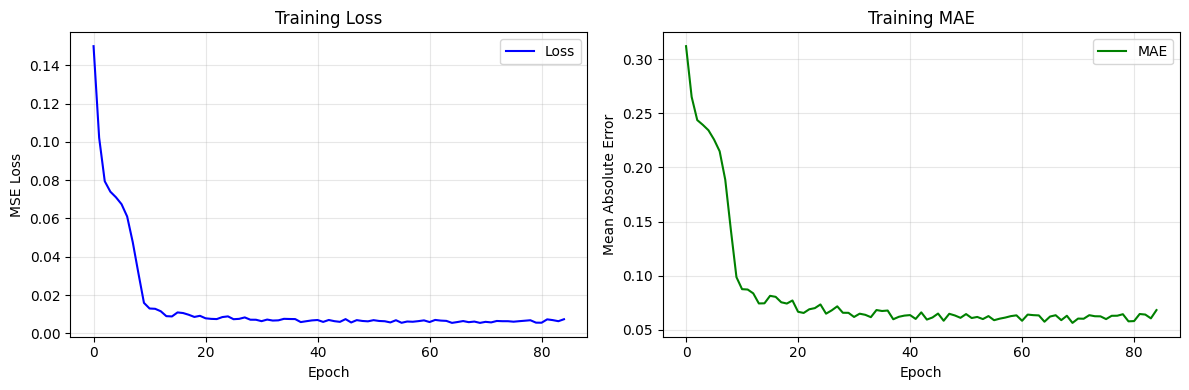

Training history saved


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE', color='green')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Training MAE')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print('Training history saved')

## 6. Iterative Forecast to December 2040

In [7]:
# Calculate forecast horizon
last_date = temp_series.index.max()
target_date = pd.Timestamp('2040-12-01')
n_periods = (target_date.year - last_date.year) * 12 + (target_date.month - last_date.month)

if n_periods <= 0:
    raise ValueError(f"Target date {target_date} is not after last observation {last_date}")

print(f"Forecasting {n_periods} months from {last_date} to {target_date}")

# Initialize with last LOOK_BACK months
forecast_input = scaled_data[-LOOK_BACK:].copy()
predictions_scaled = []

# Iterative forecasting
for step in range(n_periods):
    # Reshape for prediction
    current_input = forecast_input.reshape(1, LOOK_BACK, 1)
    
    # Predict next value
    pred = model.predict(current_input, verbose=0)[0, 0]
    predictions_scaled.append(pred)
    
    # Update sliding window
    forecast_input = np.roll(forecast_input, -1, axis=0)
    forecast_input[-1, 0] = pred

# Inverse transform to original scale
predictions_scaled = np.array(predictions_scaled).reshape(-1, 1)
predictions = scaler.inverse_transform(predictions_scaled).flatten()

# Create forecast dataframe
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_periods, freq='MS')
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'temperature_forecast': predictions
})

print("\nForecast preview:")
print(forecast_df.head())
print("...")
print(forecast_df.tail())

Forecasting 208 months from 2023-08-01 00:00:00 to 2040-12-01 00:00:00

Forecast preview:
        date  temperature_forecast
0 2023-09-01             24.626734
1 2023-10-01             20.502186
2 2023-11-01             15.133877
3 2023-12-01             11.109541
4 2024-01-01             10.625280
...
          date  temperature_forecast
203 2040-08-01             26.276066
204 2040-09-01             24.008482
205 2040-10-01             19.628092
206 2040-11-01             15.055649
207 2040-12-01             11.460497


## 7. Visualize Forecast

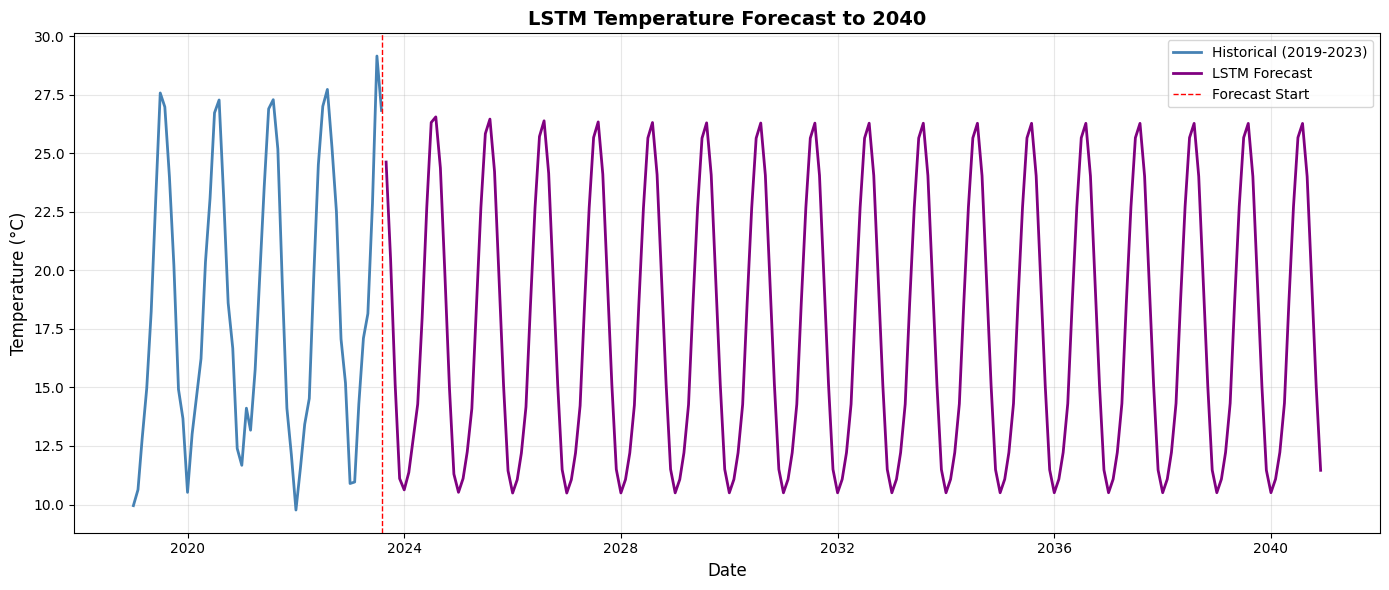

Plot saved to Results/lstm_forecast_plot.png


In [8]:
# Plot historical + forecast
plt.figure(figsize=(14, 6))

# Historical data (last 5 years)
recent_history = temp_series.loc['2019':]
plt.plot(recent_history.index, recent_history.values, label='Historical (2019-2023)', color='steelblue', linewidth=2)

# Forecast
plt.plot(forecast_df['date'], forecast_df['temperature_forecast'], label='LSTM Forecast', color='purple', linewidth=2)

plt.axvline(last_date, color='red', linestyle='--', linewidth=1, label='Forecast Start')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('LSTM Temperature Forecast to 2040', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Results/lstm_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Plot saved to Results/lstm_forecast_plot.png')

## 8. Save Model, Scaler & Forecast

In [9]:
# Save forecast CSV
forecast_path = Path('../Predictions/lstm_forecast_2040_final.csv')
forecast_df.to_csv(forecast_path, index=False)
print(f"Forecast saved to: {forecast_path}")

# Save Keras model
model_path = Path('../Models/lstm_model_final.h5')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save scaler
scaler_path = Path('../Models/lstm_scaler_final.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

print('\nLSTM pipeline complete!')

Forecast saved to: ..\Predictions\lstm_forecast_2040_final.csv
Model saved to: ..\Models\lstm_model_final.h5
Scaler saved to: ..\Models\lstm_scaler_final.pkl

LSTM pipeline complete!


## Summary Statistics

In [10]:
print("Forecast Summary:")
print(f"Mean forecast temperature: {forecast_df['temperature_forecast'].mean():.2f}°C")
print(f"Min forecast: {forecast_df['temperature_forecast'].min():.2f}°C")
print(f"Max forecast: {forecast_df['temperature_forecast'].max():.2f}°C")
print(f"Std deviation: {forecast_df['temperature_forecast'].std():.2f}°C")

# Compare with historical
hist_mean = temp_series.mean()
forecast_mean = forecast_df['temperature_forecast'].mean()
print(f"\nMean temperature change: {forecast_mean - hist_mean:+.2f}°C")
print(f"   (Historical: {hist_mean:.2f}°C → Forecast: {forecast_mean:.2f}°C)")

Forecast Summary:
Mean forecast temperature: 17.65°C
Min forecast: 10.49°C
Max forecast: 26.56°C
Std deviation: 5.71°C

Mean temperature change: -0.18°C
   (Historical: 17.83°C → Forecast: 17.65°C)
